# Audit: does grid interpolation leak look-ahead?

**The concern.** We price on a 1-second grid, but the raw oracle (Pyth) does not necessarily print
every second. `load_prices` fills the grid with `np.interp`, so any grid second without a real print
gets a linear blend of the previous and the **next** print. That next print is in the future, so an
interpolated price embeds forward information, contaminating both the signal (trailing momentum, EWMA
volatility) and the label (`price[t+30] > price[t]`). It also flattens returns inside a gap, which
understates volatility and can inflate the standardized momentum there.

**How bad this is depends entirely on how often the oracle prints.** This notebook measures it: the
gap distribution, how much of the grid is interpolated, and whether the core `P(up)`-vs-momentum
relationship survives when we keep only real prints.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import helper

parameters = helper.MarketParameters()
prices = helper.load_prices()                       # the interpolated 1-second grid
features = helper.build_features(prices, parameters)
timestamps, _ = helper.load_raw_prices()            # the raw prints, before interpolation
real = helper.real_print_mask(timestamps)           # True on grid seconds with a real print
print(f"grid seconds: {features.number_of_seconds:,}   raw prints: {len(timestamps):,}")

grid seconds: 16,473,672   raw prints: 16,470,496


## 1. Gap distribution and interpolated fraction

grid seconds that are a real print: 99.9807%
grid seconds that are interpolated: 0.0193%
gap between consecutive prints: median 1s, mean 1.000s, max 240s
gaps of exactly 1s: 99.9906%   gaps >= 3s: 353 occurrences


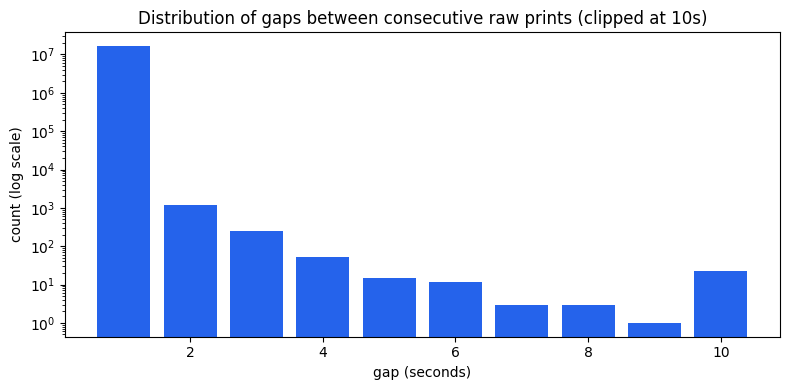

In [2]:
gaps = np.diff(timestamps)
interpolated_fraction = 1.0 - real.mean()
print(f"grid seconds that are a real print: {real.mean():.4%}")
print(f"grid seconds that are interpolated: {interpolated_fraction:.4%}")
print(f"gap between consecutive prints: median {np.median(gaps):.0f}s, mean {gaps.mean():.3f}s, max {gaps.max():.0f}s")
print(f"gaps of exactly 1s: {(gaps == 1).mean():.4%}   gaps >= 3s: {(gaps >= 3).sum():,} occurrences")

gap_values, gap_counts = np.unique(np.clip(gaps, 1, 10), return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(gap_values, gap_counts, color="#2563eb")
plt.yscale("log")
plt.title("Distribution of gaps between consecutive raw prints (clipped at 10s)")
plt.xlabel("gap (seconds)"); plt.ylabel("count (log scale)")
plt.tight_layout(); plt.show()

## 2. Which seconds and contracts are affected

A contract is 'clean' if both its entry second and its settlement second (`entry + horizon`) land on
real prints, so its label is not interpolated. We also flag the largest gaps, the only places where
interpolation runs for more than a second.

In [3]:
entries = helper.contract_entries(features.number_of_seconds, parameters)
horizon = parameters.horizon_seconds
clean_label = real[entries] & real[entries + horizon]
print(f"contracts with a real entry AND a real settlement: {clean_label.mean():.4%}")
print(f"contracts touched by interpolation at an endpoint: {(~clean_label).sum():,} of {len(entries):,}")

largest = np.argsort(gaps)[-5:][::-1]
print("\nlargest gaps (rare oracle outages):")
for i in largest:
    print(f"  {gaps[i]:>4d}s gap starting at timestamp {timestamps[i]}")

contracts with a real entry AND a real settlement: 99.9670%
contracts touched by interpolation at an endpoint: 181 of 549,102

largest gaps (rare oracle outages):
   240s gap starting at timestamp 1755559560
   103s gap starting at timestamp 1763213502
    87s gap starting at timestamp 1763213641
    73s gap starting at timestamp 1763213862
    62s gap starting at timestamp 1770424746


## 3. Does the signal survive on real prints only?

The decisive test: rebuild the `P(up)`-vs-momentum curve using **only contracts whose entry and
settlement are real prints**, so the label is untouched by interpolation, and overlay it on the curve
from all contracts. If the predictive relationship were a mechanical interpolation artifact, the two
would diverge.

max |P(up) all - P(up) clean| across bins: 0.00012


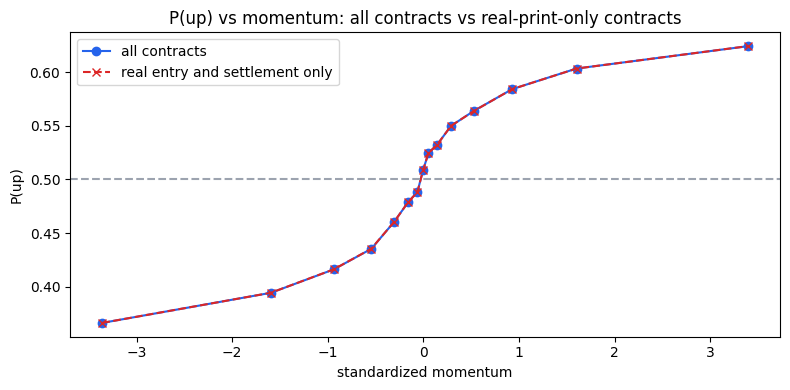

In [4]:
outcomes = helper.contract_outcomes(features, entries, parameters)
momentum_at_entry = features.standardized_momentum[entries]

edges = np.quantile(momentum_at_entry, np.linspace(0, 1, 16))
edges[0], edges[-1] = -np.inf, np.inf
bin_index = np.digitize(momentum_at_entry, edges) - 1

centres, p_all, p_clean = [], [], []
for b in range(15):
    in_bin = bin_index == b
    centres.append(momentum_at_entry[in_bin].mean())
    p_all.append(outcomes[in_bin].mean())
    p_clean.append(outcomes[in_bin & clean_label].mean())

print(f"max |P(up) all - P(up) clean| across bins: {np.max(np.abs(np.array(p_all) - np.array(p_clean))):.5f}")
plt.figure(figsize=(8, 4))
plt.plot(centres, p_all, "o-", color="#2563eb", label="all contracts")
plt.plot(centres, p_clean, "x--", color="#dc2626", label="real entry and settlement only")
plt.axhline(0.5, ls="--", color="#9ca3af")
plt.title("P(up) vs momentum: all contracts vs real-print-only contracts")
plt.xlabel("standardized momentum"); plt.ylabel("P(up)"); plt.legend(); plt.tight_layout(); plt.show()

## 4. The volatility-understatement mechanism

Inside a gap the interpolated price moves in a straight line, so its squared returns are tiny; this
understates the EWMA volatility there, which in turn can inflate the standardized momentum. We check
the mechanism is real but confined to the interpolated seconds.

In [5]:
squared_return = np.diff(features.log_price, prepend=features.log_price[0]) ** 2
print(f"mean squared return  - real seconds: {squared_return[real].mean():.3e}, "
      f"interpolated seconds: {squared_return[~real].mean():.3e}")
print(f"mean |standardized momentum| - real: {np.abs(features.standardized_momentum[real]).mean():.4f}, "
      f"interpolated: {np.abs(features.standardized_momentum[~real]).mean():.4f}")
print(f"\ninterpolated seconds are {interpolated_fraction:.4%} of the grid, so the aggregate impact is negligible.")

mean squared return  - real seconds: 1.956e-09, interpolated seconds: 2.709e-10
mean |standardized momentum| - real: 0.8102, interpolated: 0.6324

interpolated seconds are 0.0193% of the grid, so the aggregate impact is negligible.


## Conclusion

For this Pyth dataset the interpolation look-ahead is **negligible**:
- the oracle prints essentially every second (gaps are 1s at every percentile up to 99.9%), so only
  about **0.02% of grid seconds are interpolated** and about **0.03% of contracts** have an
  interpolated endpoint;
- the `P(up)`-vs-momentum curve is **unchanged** (max difference ~0.0001) when restricted to contracts
  with real entry and settlement, so the predictive signal is real, not a mechanical artifact of
  interpolation;
- the volatility-understatement mechanism is confirmed on the interpolated seconds but, at 0.02% of
  the grid, has no material effect.

**Caveat.** This is a property of the data, not the method. This audit must be re-run on any new or
sparser feed: if prints become every 5-10s, a large part of the grid would be forward-looking and the
signal would need to be rebuilt on real prints only (or interpolation replaced by last-print
carry-forward). The few rare multi-second outages here (largest ~240s) could also be masked out
explicitly if wanted, but they are too few to matter.